# Ôn metric và xem detector một frame

Chạy notebook này **sau** khi đã `conda activate cv_robotics_lab21` và `export LAB_DATA=...` (xem `HUONG_DAN.md`).

## Ba thước đo không kể cùng một câu chuyện

Chuỗi dưới đây là ID mà tracker gán cho **một** người thật qua 10 frame. Dấu `.` nghĩa là tracker **bỏ sót** frame đó (không có hộp).

- **MOTA** phạt lỗi theo **số lần**: bỏ sót, hộp giả, và mỗi lần đổi ID. Đổi ID một lần rồi giữ sai đến hết chỉ bị trừ một lần. Đổi ID liên tục bị trừ nhiều lần.
- **IDF1** nhìn cả track dài. Gán sai danh tính rồi giữ sai đến hết làm IDF1 tụt, dù MOTA vẫn cao.
- **HOTA** cân bằng hai việc: phát hiện đúng người (Detection) và giữ đúng danh tính (Association). Hai tracker cùng kém ở phần giữ ID có thể có HOTA gần nhau dù MOTA khác xa.

Số trong bảng đã tính sẵn trên ví dụ ngắn. Bạn đọc bảng và trả lời, không cần sửa công thức.

In [1]:
bang = [
    # tracker, chuỗi ID, MOTA, IDF1, HOTA, số lần đổi ID
    ("A", "1111112222", 0.90, 0.60, 0.72, 1),
    ("B", "1212121212", 0.10, 0.50, 0.71, 9),
    ("C", "111111....", 0.60, 0.75, 0.60, 0),
    ("D", "1111111111", 1.00, 1.00, 1.00, 0),
]
print(f"{'Tracker':8} {'Chuỗi':12} {'MOTA':6} {'IDF1':6} {'HOTA':6} {'Đổi ID':6}")
for row in bang:
    ten, chuoi, mota, idf1, hota, doi_id = row
    print(f"{ten:8} {chuoi:12} {mota:6.2f} {idf1:6.2f} {hota:6.2f} {doi_id:6d}")


Tracker  Chuỗi        MOTA   IDF1   HOTA   Đổi ID
A        1111112222     0.90   0.60   0.72      1
B        1212121212     0.10   0.50   0.71      9
C        111111....     0.60   0.75   0.60      0
D        1111111111     1.00   1.00   1.00      0


Điền `True` hoặc `False`, rồi chạy ô kiểm tra.

1. MOTA phạt tracker B nặng vì B đổi ID rất nhiều lần, dù mỗi lần đổi chỉ kéo dài một frame.
2. HOTA phân biệt A và B rõ hơn IDF1.
3. Tracker C bỏ sót bốn frame cuối nhưng không đổi ID, nên IDF1 của C cao hơn A trong khi MOTA của C thấp hơn A.

In [3]:
nhan_dinh_1 = True  # MOTA phạt mạnh số lần đổi ID
nhan_dinh_2 = False  # HOTA tách A và B rõ hơn IDF1
nhan_dinh_3 = True  # C: IDF1 cao hơn A, MOTA thấp hơn A

dap_an = {1: True, 2: False, 3: True}
ban_chon = {1: nhan_dinh_1, 2: nhan_dinh_2, 3: nhan_dinh_3}
for cau, dung in dap_an.items():
    if ban_chon[cau] is None:
        print(f"Câu {cau}: chưa điền")
    elif ban_chon[cau] == dung:
        print(f"Câu {cau}: đúng")
    else:
        print(f"Câu {cau}: xem lại bảng — HOTA của A và B gần nhau, IDF1 cách xa hơn")


Câu 1: đúng
Câu 2: đúng
Câu 3: đúng


## Detector chưa phải tracker

YOLO nhìn **từng ảnh một**. Nó vẽ hộp quanh người và cho một điểm tin cậy. Nó **không** nhớ người ở frame trước, nên **không có ID**.

Tracker nhận các hộp đó rồi mới gán ID theo thời gian. Đổi `--conf` hoặc `--iou` là đổi ngưỡng của YOLO (hộp nào được giữ), không phải ngưỡng bên trong tracker.

Hai ô dưới chạy `yolo26n.pt` trên **một** ảnh của `video_1`. Cả lớp dùng chung trọng số này, kích thước ảnh 640 px, chỉ lớp người.

In [4]:
%env LAB_DATA=data_lab21

env: LAB_DATA=data_lab21


Ảnh: 000001.jpg
conf=0.3, iou=0.5 -> 6 hộp người. Chưa có ID.


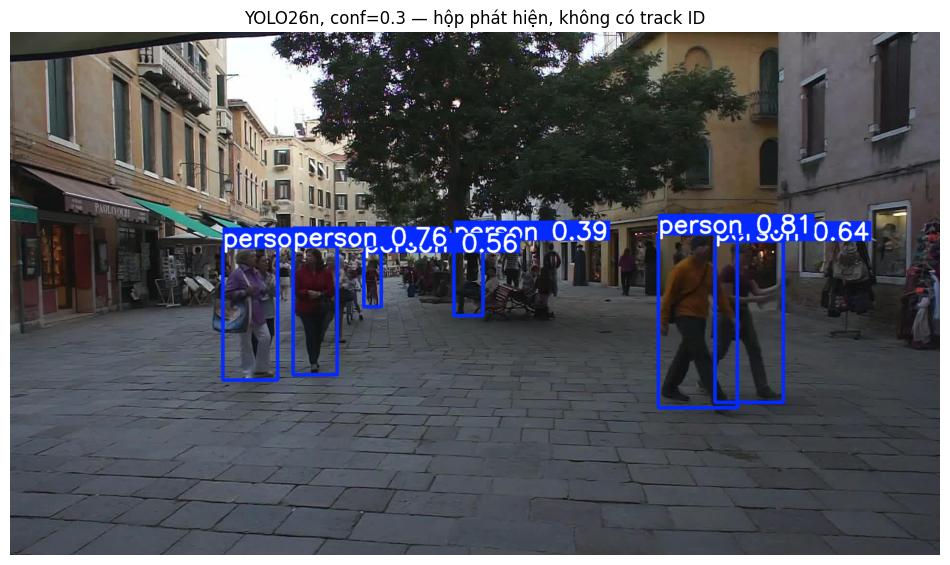

In [5]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

IMG_SIZE = 640
PERSON_CLASS_ID = 0
DETECTOR_WEIGHTS = "yolo26n.pt"

lab_data = os.environ.get("LAB_DATA", "").strip()
frame_path = None
if not lab_data:
    print("Chưa có biến LAB_DATA.")
    print("Trong terminal, trước khi mở notebook:")
    print('  export LAB_DATA=/đường/dẫn/lab_data')
    print("Rồi chọn kernel cv_robotics_lab21 và chạy lại từ ô này.")
else:
    frames = sorted((Path(lab_data) / "video_1" / "img1").glob("*.jpg"))
    if not frames:
        print(f"Không thấy ảnh jpg trong {lab_data}/video_1/img1")
    else:
        frame_path = frames[0]
        print(f"Ảnh: {frame_path.name}")

detector = None
frame_bgr = None
if frame_path is not None:
    frame_bgr = cv2.imread(str(frame_path))
    detector = YOLO(DETECTOR_WEIGHTS)
    result = detector.predict(
        frame_bgr,
        conf=0.3,
        iou=0.5,
        imgsz=IMG_SIZE,
        classes=[PERSON_CLASS_ID],
        verbose=False,
    )[0]
    n_boxes = 0 if result.boxes is None else len(result.boxes)
    print(f"conf=0.3, iou=0.5 -> {n_boxes} hộp người. Chưa có ID.")
    vis = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 7))
    plt.imshow(vis)
    plt.axis("off")
    plt.title("YOLO26n, conf=0.3 — hộp phát hiện, không có track ID")
    plt.show()


Giả thiết: Cảnh dông người, thậm chí có người đứng sát nhau, thuật toán có thể không phân biệt được.

In [6]:
if detector is None or frame_bgr is None:
    print("Bỏ qua ô này. Chạy ô detector phía trên khi đã có LAB_DATA.")
else:
    for conf in (0.15, 0.5):
        result = detector.predict(
            frame_bgr,
            conf=conf,
            iou=0.5,
            imgsz=IMG_SIZE,
            classes=[PERSON_CLASS_ID],
            verbose=False,
        )[0]
        n_boxes = 0 if result.boxes is None else len(result.boxes)
        print(f"conf={conf:.2f} -> {n_boxes} hộp người")
    print("conf thấp thường ra nhiều hộp hơn, kể cả hộp trên nền. conf cao dễ bỏ sót người nhỏ hoặc tối.")


conf=0.15 -> 14 hộp người
conf=0.50 -> 5 hộp người
conf thấp thường ra nhiều hộp hơn, kể cả hộp trên nền. conf cao dễ bỏ sót người nhỏ hoặc tối.


## Sang bước tracking

ID chỉ xuất hiện khi bạn chạy `scripts/run_tracking.py`. Script đó lấy hộp YOLO rồi đưa vào tracker (`bytetrack`, `ocsort`, `botsort`, `strongsort`, hoặc `deepocsort`).

Khi viết báo cáo, tách hai loại lỗi:

- Đổi ID liên tục (kiểu B) làm MOTA tụt mạnh.
- Đổi ID một lần rồi giữ sai (kiểu A) vẫn có MOTA cao. IDF1 và video lộ hậu quả rõ hơn.
- Bỏ sót người (kiểu C) khác với gán nhầm người.

Chỉ `video_1` có bảng số. Bốn video kia bạn mô tả đúng kiểu lỗi này bằng mắt.

In [9]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_1/img1" \
  --seq-name video_1 \
  --tracker bytetrack --conf 0.3 --iou 0.5 \
  --out runs/thu_nhanh --save-video --max-frames 150 \
  --device cuda:0

[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=bytetrack

[video_1] tracker=bytetrack conf=0.3 iou=0.5 -> 150 frame trong 12.0s (12.5 FPS)
  File nộp bài: runs\thu_nhanh\video_1.txt
  Video xem thử: runs\thu_nhanh\video_1_preview.mp4


In [10]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_2/img1" \
  --seq-name video_2 \
  --tracker bytetrack --conf 0.3 --iou 0.5 \
  --out runs/thu_v2_byte --save-video --max-frames 150 \
  --device cuda:0

[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=bytetrack

[video_2] tracker=bytetrack conf=0.3 iou=0.5 -> 150 frame trong 11.7s (12.8 FPS)
  File nộp bài: runs\thu_v2_byte\video_2.txt
  Video xem thử: runs\thu_v2_byte\video_2_preview.mp4


In [4]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_2/img1" \
  --seq-name video_2 \
  --tracker strongsort --conf 0.3 --iou 0.5 \
  --out runs/thu_v2_strong --save-video --max-frames 150 \
  --device cuda:0

[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=strongsort
              tracker này dùng Re-ID: osnet_x0_25_msmt17.pt (tự tải nếu chưa có)

[video_2] tracker=strongsort conf=0.3 iou=0.5 -> 150 frame trong 21.4s (7.0 FPS)
  File nộp bài: runs\thu_v2_strong\video_2.txt
  Video xem thử: runs\thu_v2_strong\video_2_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\appearance\reid_model_factory.py:160: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be l

In [6]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_2/img1" \
  --seq-name video_2 \
  --tracker strongsort --conf 0.1 --iou 0.5 \
  --out runs/thu_v2_conf01 --save-video --max-frames 150 \
  --device cuda:0

[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=strongsort
              tracker này dùng Re-ID: osnet_x0_25_msmt17.pt (tự tải nếu chưa có)

[video_2] tracker=strongsort conf=0.1 iou=0.5 -> 150 frame trong 21.1s (7.1 FPS)
  File nộp bài: runs\thu_v2_conf01\video_2.txt
  Video xem thử: runs\thu_v2_conf01\video_2_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\appearance\reid_model_factory.py:160: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be l

In [1]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_2/img1" \
  --seq-name video_2 \
  --tracker strongsort --conf 0.2 --iou 0.5 \
  --out runs/nop_bai --save-video \
  --device cuda:0
  # code 1 : missing nhieu , code 2: blip nhieu, code 3: chap nhan đc 


[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=strongsort
              tracker này dùng Re-ID: osnet_x0_25_msmt17.pt (tự tải nếu chưa có)

[video_2] tracker=strongsort conf=0.2 iou=0.5 -> 1050 frame trong 179.5s (5.9 FPS)
  File nộp bài: runs\nop_bai\video_2.txt
  Video xem thử: runs\nop_bai\video_2_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\appearance\reid_model_factory.py:160: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be l

In [ ]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_3/img1" \
  --seq-name video_3 \
  --tracker bytetrack --conf 0.3 --iou 0.5 \
  --out runs/thu_v3_byte --save-video --max-frames 150 \
  --device cuda:0
  #on dinh, human size qua nho thi khong capture thanh cong

[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=bytetrack

[video_3] tracker=bytetrack conf=0.3 iou=0.5 -> 150 frame trong 5.8s (25.7 FPS)
  File nộp bài: runs\thu_v3_byte\video_3.txt
  Video xem thử: runs\thu_v3_byte\video_3_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [5]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_3/img1" \
  --seq-name video_3 \
  --tracker botsort --conf 0.3 --iou 0.5 \
  --out runs/thu_v3_bot --save-video --max-frames 150 \
  --device cuda:0


[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=botsort
              tracker này dùng Re-ID: osnet_x0_25_msmt17.pt (tự tải nếu chưa có)

[video_3] tracker=botsort conf=0.3 iou=0.5 -> 150 frame trong 9.6s (15.7 FPS)
  File nộp bài: runs\thu_v3_bot\video_3.txt
  Video xem thử: runs\thu_v3_bot\video_3_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\appearance\reid_model_factory.py:160: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be l

In [6]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_3/img1" \
  --seq-name video_3 \
  --tracker botsort --conf 0.3 --iou 0.5 \
  --out runs/nop_bai --save-video \
  --device cuda:0

[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=botsort
              tracker này dùng Re-ID: osnet_x0_25_msmt17.pt (tự tải nếu chưa có)

[video_3] tracker=botsort conf=0.3 iou=0.5 -> 837 frame trong 55.3s (15.1 FPS)
  File nộp bài: runs\nop_bai\video_3.txt
  Video xem thử: runs\nop_bai\video_3_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\appearance\reid_model_factory.py:160: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be l

In [ ]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_4/img1" \
  --seq-name video_4 \
  --tracker bytetrack --conf 0.2 --iou 0.5 \
  --out runs/thu_v4_byte --save-video --max-frames 150 \
  --device cuda:0
# input có bóng trên nền, model không bị hallucinate, human bé bé chưa detect được

[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=bytetrack

[video_4] tracker=bytetrack conf=0.2 iou=0.5 -> 150 frame trong 13.3s (11.2 FPS)
  File nộp bài: runs\thu_v4_byte\video_4.txt
  Video xem thử: runs\thu_v4_byte\video_4_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_4/img1" \
  --seq-name video_4 \
  --tracker bytetrack --conf 0.15 --iou 0.5 \
  --out runs/thu_v4_byte_c15 --save-video --max-frames 150 \
  --device cuda:0
# vẫn bị mù, id hình như bị blip

[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=bytetrack

[video_4] tracker=bytetrack conf=0.15 iou=0.5 -> 150 frame trong 10.5s (14.2 FPS)
  File nộp bài: runs\thu_v4_byte_c15\video_4.txt
  Video xem thử: runs\thu_v4_byte_c15\video_4_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_4/img1" \
  --seq-name video_4 \
  --tracker strongsort --conf 0.15 --iou 0.5 \
  --out runs/thu_v4_strong --save-video --max-frames 150 \
  --device cuda:0
#nice

[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=strongsort
              tracker này dùng Re-ID: osnet_x0_25_msmt17.pt (tự tải nếu chưa có)

[video_4] tracker=strongsort conf=0.15 iou=0.5 -> 150 frame trong 17.7s (8.5 FPS)
  File nộp bài: runs\thu_v4_strong\video_4.txt
  Video xem thử: runs\thu_v4_strong\video_4_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\appearance\reid_model_factory.py:160: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be l

In [10]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_4/img1" \
  --seq-name video_4 \
  --tracker strongsort --conf 0.15 --iou 0.5 \
  --out runs/nop_bai --save-video \
  --device cuda:0


[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=strongsort
              tracker này dùng Re-ID: osnet_x0_25_msmt17.pt (tự tải nếu chưa có)

[video_4] tracker=strongsort conf=0.15 iou=0.5 -> 900 frame trong 115.5s (7.8 FPS)
  File nộp bài: runs\nop_bai\video_4.txt
  Video xem thử: runs\nop_bai\video_4_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\appearance\reid_model_factory.py:160: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be l

In [ ]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_5/img1" \
  --seq-name video_5 \
  --tracker bytetrack --conf 0.25 --iou 0.5 \
  --out runs/thu_v5_byte --save-video --max-frames 150 \
  --device cuda:0
  #human overlap -> lost

[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=bytetrack

[video_5] tracker=bytetrack conf=0.25 iou=0.5 -> 150 frame trong 10.4s (14.4 FPS)
  File nộp bài: runs\thu_v5_byte\video_5.txt
  Video xem thử: runs\thu_v5_byte\video_5_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [12]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_5/img1" \
  --seq-name video_5 \
  --tracker botsort --conf 0.25 --iou 0.5 \
  --out runs/thu_v5_bot --save-video --max-frames 150 \
  --device cuda:0


[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=botsort
              tracker này dùng Re-ID: osnet_x0_25_msmt17.pt (tự tải nếu chưa có)

[video_5] tracker=botsort conf=0.25 iou=0.5 -> 150 frame trong 18.5s (8.1 FPS)
  File nộp bài: runs\thu_v5_bot\video_5.txt
  Video xem thử: runs\thu_v5_bot\video_5_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\appearance\reid_model_factory.py:160: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be l

In [13]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_5/img1" \
  --seq-name video_5 \
  --tracker botsort --conf 0.25 --iou 0.5 \
  --out runs/nop_bai --save-video \
  --device cuda:0


[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=botsort
              tracker này dùng Re-ID: osnet_x0_25_msmt17.pt (tự tải nếu chưa có)

[video_5] tracker=botsort conf=0.25 iou=0.5 -> 750 frame trong 97.7s (7.7 FPS)
  File nộp bài: runs\nop_bai\video_5.txt
  Video xem thử: runs\nop_bai\video_5_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\appearance\reid_model_factory.py:160: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be l

In [14]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_1/img1" \
  --seq-name video_1 \
  --tracker bytetrack --conf 0.3 --iou 0.5 \
  --out runs/thu_v1_byte --save-video \
  --device cuda:0


[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=bytetrack

[video_1] tracker=bytetrack conf=0.3 iou=0.5 -> 600 frame trong 40.7s (14.7 FPS)
  File nộp bài: runs\thu_v1_byte\video_1.txt
  Video xem thử: runs\thu_v1_byte\video_1_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [18]:
!python scripts/evaluate_practice.py \
  --trackeval-root TrackEval \
  --lab-data-root data_lab21 \
  --submission runs/thu_v1_byte/video_1.txt \
  --run-name v1_bytetrack


Đang chấm video luyện:
  c:\Users\Admin\miniconda3\envs\megraph\python.exe TrackEval\scripts\run_mot_challenge.py --GT_FOLDER TrackEval\data\gt\mot_challenge --TRACKERS_FOLDER TrackEval\data\trackers\mot_challenge --BENCHMARK MOT17 --SPLIT_TO_EVAL train --SEQ_INFO video_1 --TRACKERS_TO_EVAL v1_bytetrack --METRICS HOTA CLEAR Identity --USE_PARALLEL False

Error importing BURST due to missing underlying dependency: No module named 'pycocotools'

Eval Config:
USE_PARALLEL         : False                         
NUM_PARALLEL_CORES   : 8                             
BREAK_ON_ERROR       : True                          
RETURN_ON_ERROR      : False                         
LOG_ON_ERROR         : c:\AI\vinai20k\K4-Track4-Day22-Tracking-Student\TrackEval\error_log.txt
PRINT_RESULTS        : True                          
PRINT_ONLY_COMBINED  : False                         
PRINT_CONFIG         : True                          
TIME_PROGRESS        : True                          
DISPLAY_LESS

c:\AI\vinai20k\K4-Track4-Day22-Tracking-Student\scripts\evaluate_practice.py:35: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  if not hasattr(np, "float"):
c:\AI\vinai20k\K4-Track4-Day22-Tracking-Student\scripts\evaluate_practice.py:37: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https:

In [16]:
!python scripts/run_tracking.py \
  --source "data_lab21/video_1/img1" \
  --seq-name video_1 \
  --tracker botsort --conf 0.3 --iou 0.5 \
  --out runs/thu_v1_bot --save-video \
  --device cuda:0


[nạp mô hình] detector=yolo26n.pt imgsz=640 tracker=botsort
              tracker này dùng Re-ID: osnet_x0_25_msmt17.pt (tự tải nếu chưa có)

[video_1] tracker=botsort conf=0.3 iou=0.5 -> 600 frame trong 71.2s (8.4 FPS)
  File nộp bài: runs\thu_v1_bot\video_1.txt
  Video xem thử: runs\thu_v1_bot\video_1_preview.mp4


c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\utils\checks.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\Admin\miniconda3\envs\megraph\lib\site-packages\boxmot\appearance\reid_model_factory.py:160: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be l

In [19]:
!python scripts/evaluate_practice.py \
  --trackeval-root TrackEval \
  --lab-data-root data_lab21 \
  --submission runs/thu_v1_bot/video_1.txt \
  --run-name v1_botsort


Đang chấm video luyện:
  c:\Users\Admin\miniconda3\envs\megraph\python.exe TrackEval\scripts\run_mot_challenge.py --GT_FOLDER TrackEval\data\gt\mot_challenge --TRACKERS_FOLDER TrackEval\data\trackers\mot_challenge --BENCHMARK MOT17 --SPLIT_TO_EVAL train --SEQ_INFO video_1 --TRACKERS_TO_EVAL v1_botsort --METRICS HOTA CLEAR Identity --USE_PARALLEL False

Error importing BURST due to missing underlying dependency: No module named 'pycocotools'

Eval Config:
USE_PARALLEL         : False                         
NUM_PARALLEL_CORES   : 8                             
BREAK_ON_ERROR       : True                          
RETURN_ON_ERROR      : False                         
LOG_ON_ERROR         : c:\AI\vinai20k\K4-Track4-Day22-Tracking-Student\TrackEval\error_log.txt
PRINT_RESULTS        : True                          
PRINT_ONLY_COMBINED  : False                         
PRINT_CONFIG         : True                          
TIME_PROGRESS        : True                          
DISPLAY_LESS_P

c:\AI\vinai20k\K4-Track4-Day22-Tracking-Student\scripts\evaluate_practice.py:35: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  if not hasattr(np, "float"):
c:\AI\vinai20k\K4-Track4-Day22-Tracking-Student\scripts\evaluate_practice.py:37: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https:

In [22]:
import shutil
shutil.copy("runs/thu_v1_bot/video_1.txt", "runs/nop_bai/video_1.txt")
shutil.copy("runs/thu_v1_bot/video_1_preview.mp4", "runs/nop_bai/video_1_preview.mp4")

'runs/nop_bai/video_1_preview.mp4'